In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import ipywidgets as widgets
from IPython.display import display
import trimesh
from torch import autograd as Grad
import random
import math


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay

# Define the number of grid points along one side of the triangle
N = 100

# Define vertices of an equilateral triangle
L = 1.0  # Side length of the triangle
vertices = np.array([[0, 0], [L, 0], [L / 2, np.sqrt(3) / 2 * L]])

# Generate triangular grid points
x = np.linspace(0, L, N)
y = np.linspace(0, np.sqrt(3) / 2 * L, N)
X, Y = np.meshgrid(x, y)
points = np.vstack([X.ravel(), Y.ravel()]).T

# Function to check if points are inside the triangle
def inside_triangle(p, v):
    A = 0.5 * (-v[1, 1] * v[2, 0] + v[0, 1] * (-v[1, 0] + v[2, 0]) + v[0, 0] * (v[1, 1] - v[2, 1]) + v[1, 0] * v[2, 1])
    s = 1 / (2 * A) * (v[0, 1] * v[2, 0] - v[0, 0] * v[2, 1] + (v[2, 1] - v[0, 1]) * p[:, 0] + (v[0, 0] - v[2, 0]) * p[:, 1])
    t = 1 / (2 * A) * (v[0, 0] * v[1, 1] - v[0, 1] * v[1, 0] + (v[0, 1] - v[1, 1]) * p[:, 0] + (v[1, 0] - v[0, 0]) * p[:, 1])
    return (s >= 0) & (t >= 0) & (s + t <= 1)

inside = inside_triangle(points, vertices)
points = points[inside]
points = np.concatenate([points, np.array([1, -1]) * points[N:]])

n = len(points)

# Delaunay triangulation
tri = Delaunay(points)

# Construct Laplace matrix
A = np.zeros((n, n))
b = np.zeros(n)

# Function to find neighbors
def find_neighbors(index):
    dists = np.linalg.norm(points - points[index], axis=1)
    return np.where((dists < L / N * 1.5) & (dists > 1e-10))[0]

# Solve for new_x
for i, (x, y) in enumerate(points):
    if np.isclose(y, 0, rtol=1e-2, atol=1e-2):  
        neighbors = find_neighbors(i)
        A[i, i] = -1
        A[i, neighbors] = 1 / len(neighbors)
    elif np.isclose(y + np.tan(np.pi / 3) * (x - 1), 0, rtol=1e-2, atol=1e-2):
        A[i, i] = 1
        b[i] = 2*x
    elif np.isclose(y - np.tan(np.pi / 3) * (x), 0, rtol=1e-2, atol=1e-2) :
        A[i, i] = 1
        b[i] = 3*(x-0.5)+1
    elif np.isclose(-y + np.tan(np.pi / 3) * (x - 1), 0, rtol=1e-2, atol=1e-2):
        A[i, i] = 1
        b[i] = 2*x
        
    elif np.isclose(-y - np.tan(np.pi / 3) * (x), 0, rtol=1e-2, atol=1e-2) :
        A[i, i] = 1
        b[i] = 3*(x-0.5)+1
    else:
        neighbors = find_neighbors(i)
        A[i, i] = -len(neighbors)
        A[i, neighbors] = 1

new_x, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

# Solve for new_y
b = np.zeros(n)
for i, (x, y) in enumerate(points):
    if np.isclose(y, 0, rtol=1e-2, atol=1e-2):
        neighbors = find_neighbors(i)
        A[i, i] = -1
        A[i, neighbors] = 1 / len(neighbors)
    elif np.isclose(y + np.tan(np.pi / 3) * (x - 1), 0, rtol=1e-2, atol=1e-2) or \
         np.isclose(y - np.tan(np.pi / 3) * (x), 0, rtol=1e-2, atol=1e-2):
        A[i, i] = 1
        b[i] = y
        
    elif np.isclose(-y + np.tan(np.pi / 3) * (x - 1), 0, rtol=1e-2, atol=1e-2) or \
         np.isclose(-y - np.tan(np.pi / 3) * (x), 0, rtol=1e-2, atol=1e-2):
        A[i, i] = 1
        b[i] = y
        
    else:
        neighbors = find_neighbors(i)
        A[i, i] = -len(neighbors)
        A[i, neighbors] = 1

new_y, _, _, _ = np.linalg.lstsq(A, b, rcond=None)



In [17]:
# Function to compute gradient
def compute_gradient(u):
    du_dx = np.zeros(n)
    du_dy = np.zeros(n)
    
    for i, (x, y) in enumerate(points):
        neighbors = find_neighbors(i)
        if len(neighbors) > 0:
            dx = points[neighbors, 0] - x
            dy = points[neighbors, 1] - y
            du = u[neighbors] - u[i]
            weights = 1 / (dx**2 + dy**2 + 1e-10)
            du_dx[i] = np.sum(weights * du * dx) / np.sum(weights)
            du_dy[i] = np.sum(weights * du * dy) / np.sum(weights)
    
    return du_dx, du_dy

# Plotting function
def plot_results(u, title):
    du_dx, du_dy = compute_gradient(u)
    magnitude = np.sqrt(du_dx**2 + du_dy**2)

    fig, axes = plt.subplots(2, 2, figsize=(12, 12))

    # Contour plot
    ax1 = axes[0, 0]
    tcf = ax1.tricontourf(points[:, 0], points[:, 1], tri.simplices, u, cmap='viridis')
    fig.colorbar(tcf, ax=ax1, label='Potential')
    ax1.triplot(points[:, 0], points[:, 1], tri.simplices, color='black', alpha=0.3)
    ax1.set_title(f"Contour Plot: {title}")
    ax1.axis("equal")

    # Quiver plot for gradient
    ax2 = axes[0, 1]
    ax2.triplot(points[:, 0], points[:, 1], tri.simplices, color='black', alpha=0.3)
    ax2.quiver(points[::10, 0], points[::10, 1], -du_dx[::10], -du_dy[::10], color='red', angles='xy', scale_units='xy', scale=0.002, alpha=0.7)
    ax2.set_title(f"Quiver Plot: {title}")
    ax2.axis("equal")

    # Magnitude of gradient
    ax3 = axes[1, 0]
    sc = ax3.scatter(points[:, 0], points[:, 1], c=magnitude, cmap='plasma')
    fig.colorbar(sc, ax=ax3, label='Gradient Magnitude')
    ax3.set_title(f"Magnitude of Gradient: {title}")
    ax3.axis("equal")

    # Blank plot
    ax4 = axes[1, 1]
    ax4.set_title(f"Blank Plot: {title}")
    ax4.axis("off")

    plt.tight_layout()
    plt.show()



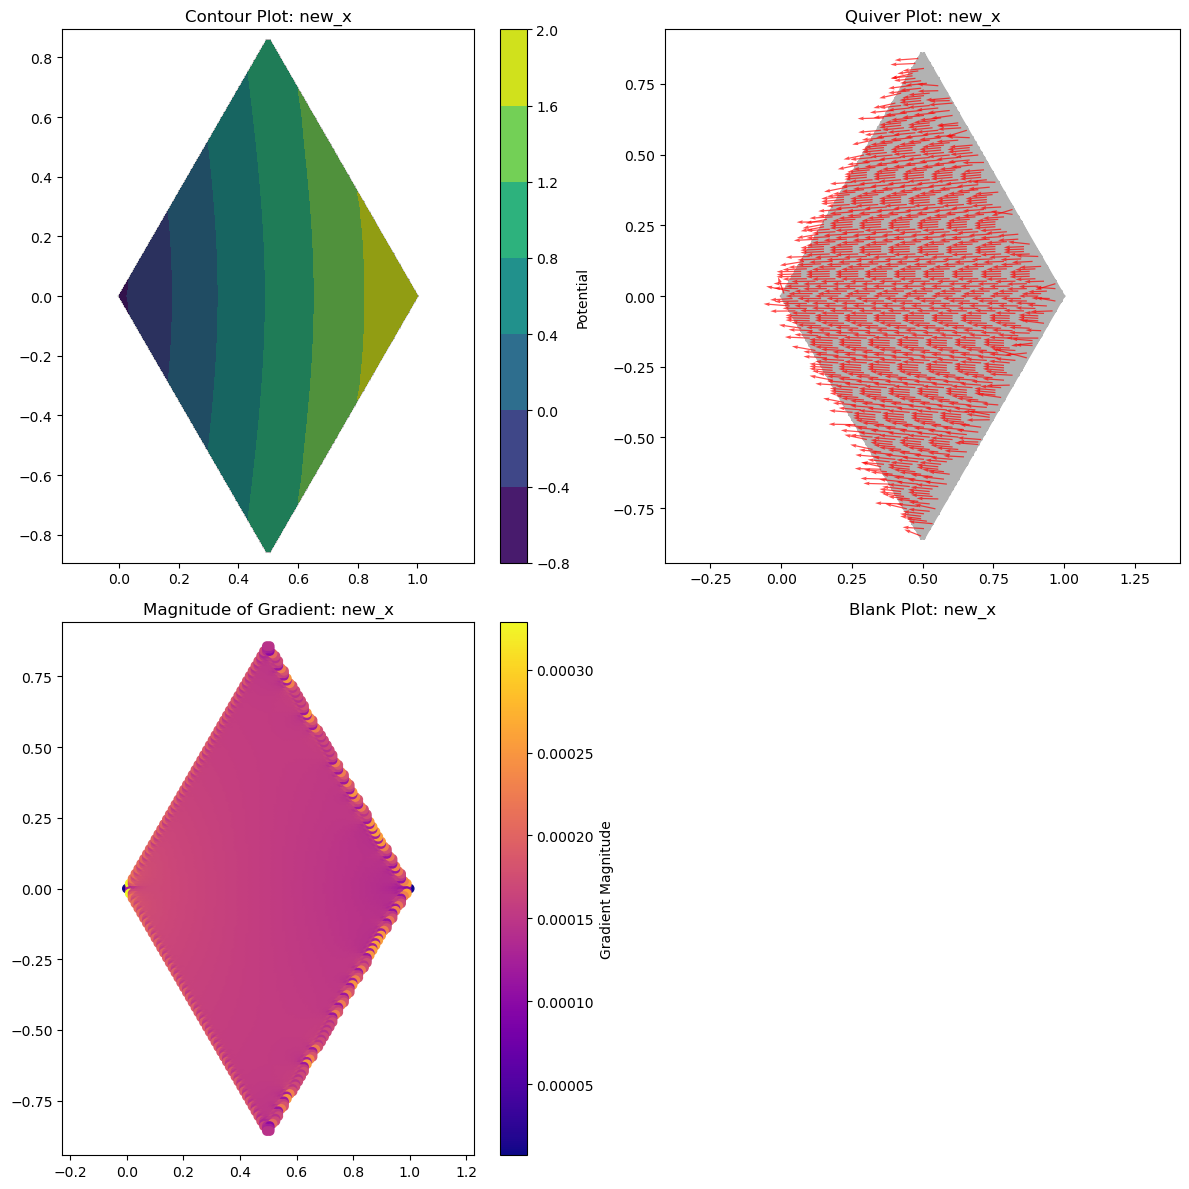

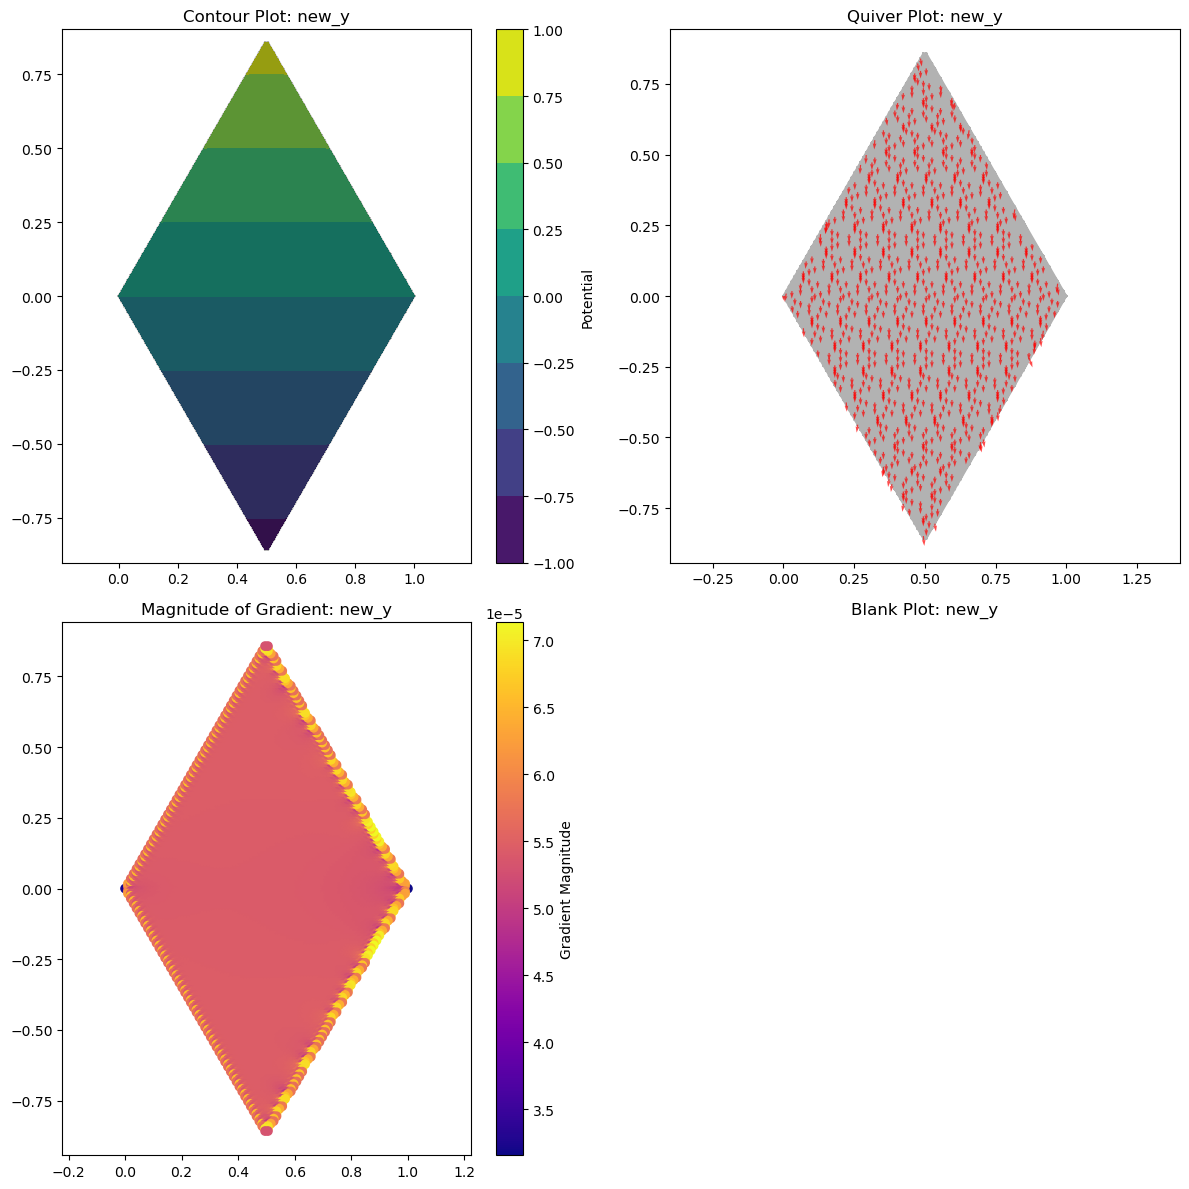

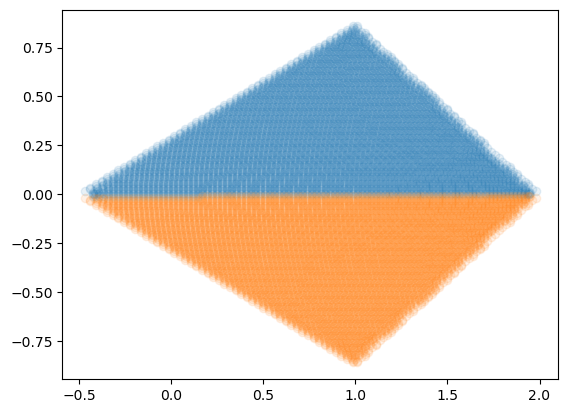

In [18]:
# Plot results for new_x and new_y
plot_results(new_x, "new_x")
plot_results(new_y, "new_y")



plt.scatter(new_x[:N**2//2], new_y[:N**2//2], alpha=0.1)
plt.scatter(new_x[N**2//2:], new_y[N**2//2:], alpha=0.1)
plt.show()

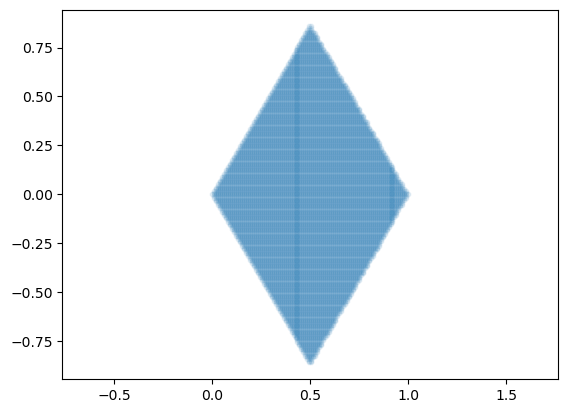

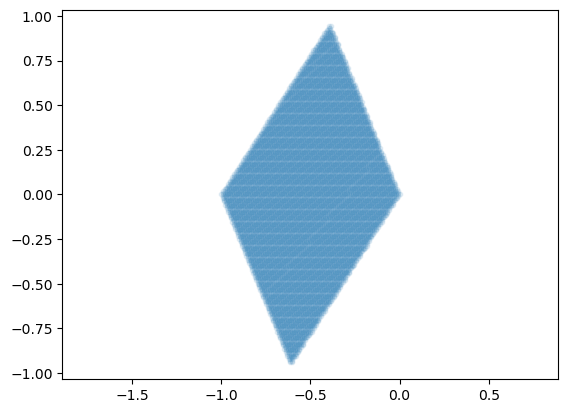

In [13]:
X=points[:,0]
Y=points[:,1]
plt.scatter(X,Y, alpha=0.1, s=10)
plt.axis('equal')
plt.show()

plt.scatter(X+0.1270*Y-1,1.0981*Y, alpha=0.1, s=10)
plt.axis('equal')
plt.show()